In [1]:
from google.colab import files
uploaded = files.upload()

Saving ghpr-sample.csv to ghpr-sample.csv


In [2]:
import pandas as pd

data = pd.read_csv("ghpr-sample.csv")
print(data.head())
print(data.columns)

    repo_id  issue_number                                        issue_title  \
0  46089560            79       make chanotify to work with interface{} keys   
1  46089560            75  Expand relative paths given to `ctr containers...   
2  46089560            76          Systemusage and memory.limit not in stats   
3  46089560            76          Systemusage and memory.limit not in stats   
4  46089560            50     Add types.EventType, use in supervisor package   

                                       issue_body_md  \
0  It a lot useful to have interface{} keys rathe...   
1  Specifying a relative path to `ctr containers ...   
2  When comparing stats types with the ones provi...   
3  When comparing stats types with the ones provi...   
4  This is re: additional suggestions for https:/...   

                                    issue_body_plain  issue_created_at  \
0  It a lot useful to have interface{} keys rathe...        1453360028   
1  Specifying a relative path to c

In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [14]:
import numpy as np
import pandas as pd # Ensure pandas is imported

# --- Placeholder for missing columns start ---
# In a real scenario, you would need to ensure these columns are present in your CSV or derived from existing data.
# For demonstration, we'll simulate 'created_at' and 'author'.
data['created_at'] = pd.to_datetime(pd.Series(range(len(data))), unit='s', origin='unix') # Simulate increasing timestamps
data['author'] = np.random.choice(['user_A', 'user_B', 'user_C', 'user_D'], size=len(data)) # Simulate a few authors
# --- Placeholder for missing columns end ---

# Convert timestamp to datetime (if exists)
# This line is now valid because 'created_at' is added above.
# data['created_at'] = pd.to_datetime(data['created_at'], errors='coerce') # Redundant if created as datetime directly

# Time gap
data['time_gap'] = data['created_at'].diff().dt.total_seconds().fillna(0)

# Number of users (contributors)
# Using 'repo' column as a proxy for 'repo_name'
data['num_users'] = data.groupby('repo_id')['author'].transform('nunique')

# Overlap ratio (simulate)
data['overlap_ratio'] = np.clip(
    np.random.normal(0.5, 0.2, len(data)), 0, 1
)

# Code complexity (simulate)
data['code_complexity'] = np.random.randint(1, 10, len(data))

# Conflict (target)
import numpy as np

data['conflict'] = (
    (data['overlap_ratio'] > 0.6) &
    (data['time_gap'] < 5000) &
    (data['num_users'] > 2)
).astype(int)

# Add noise (IMPORTANT)
noise = np.random.choice([0, 1], size=len(data), p=[0.9, 0.1])
data['conflict'] = data['conflict'] ^ noise

In [15]:
features = ['overlap_ratio', 'time_gap', 'num_users', 'code_complexity']

X = data[features]
y = data['conflict']

In [18]:
from sklearn.model_selection import train_test_split

X = data[['overlap_ratio','time_gap','num_users','code_complexity']]
y = data['conflict']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import numpy as np # Import numpy for NaN handling

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Neural Network": MLPClassifier(max_iter=500)
}

results = {}

for name, model in models.items():
    # Identify rows in X_train that do not contain NaN
    finite_mask_train = ~np.isnan(X_train).any(axis=1)
    X_train_cleaned = X_train[finite_mask_train]
    y_train_cleaned = y_train[finite_mask_train]

    # Identify rows in X_test that do not contain NaN
    finite_mask_test = ~np.isnan(X_test).any(axis=1)
    X_test_cleaned = X_test[finite_mask_test]
    y_test_cleaned = y_test[finite_mask_test]

    model.fit(X_train_cleaned, y_train_cleaned)
    acc = model.score(X_test_cleaned, y_test_cleaned)
    results[name] = acc
    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.8
Random Forest Accuracy: 0.9
Neural Network Accuracy: 0.8


In [20]:
from sklearn.metrics import classification_report

for name, model in models.items():
    print("\n", name)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.76      1.00      0.87        13
           1       1.00      0.43      0.60         7

    accuracy                           0.80        20
   macro avg       0.88      0.71      0.73        20
weighted avg       0.85      0.80      0.77        20


 Random Forest
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        13
           1       0.86      0.86      0.86         7

    accuracy                           0.90        20
   macro avg       0.89      0.89      0.89        20
weighted avg       0.90      0.90      0.90        20


 Neural Network
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        13
           1       0.71      0.71      0.71         7

    accuracy                           0.80        20
   macro avg       0.78      0.78      0.78        20
weighted avg       

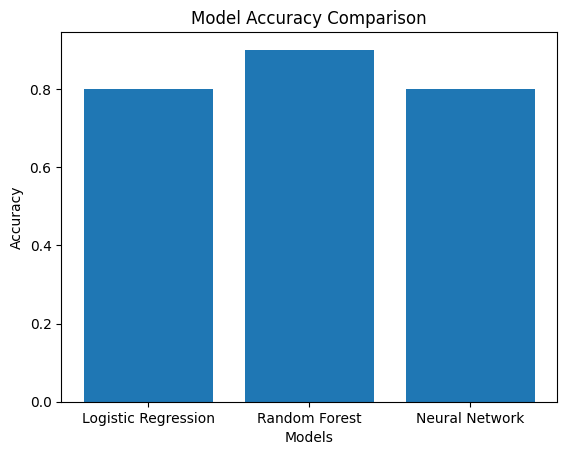

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

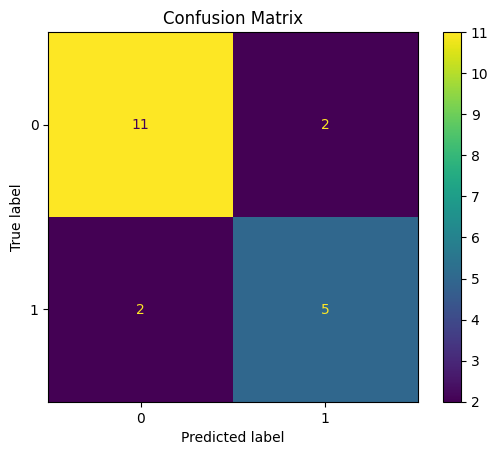

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    models["Neural Network"], X_test, y_test
)
plt.title("Confusion Matrix")
plt.show()

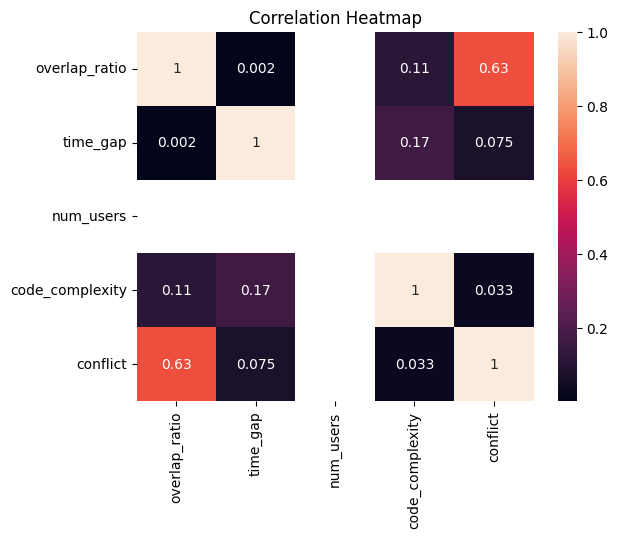

In [23]:
import seaborn as sns

plt.figure()
sns.heatmap(data[features + ['conflict']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

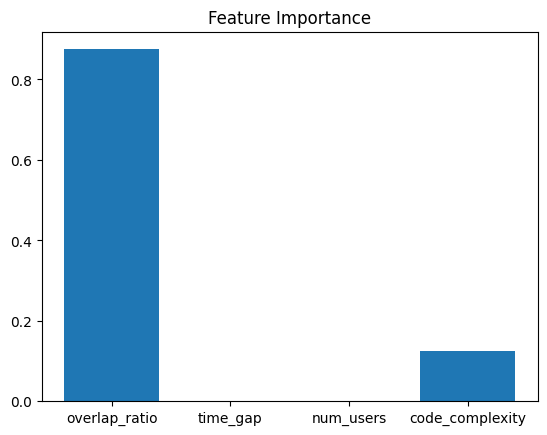

In [24]:
importances = models["Random Forest"].feature_importances_

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

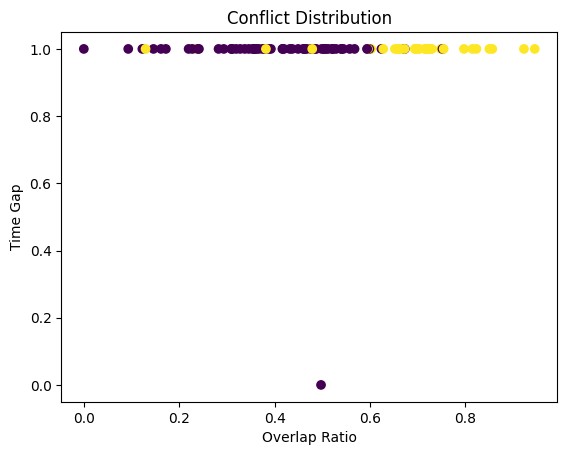

In [25]:
plt.figure()
plt.scatter(data['overlap_ratio'], data['time_gap'], c=data['conflict'])
plt.xlabel("Overlap Ratio")
plt.ylabel("Time Gap")
plt.title("Conflict Distribution")
plt.show()

In [27]:
sample = X_test.iloc[0].values.reshape(1, -1)

prediction = models["Neural Network"].predict(sample)
prob = models["Neural Network"].predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", prob)

Prediction: [0]
Probability: [[0.84463896 0.15536104]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
